In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
flights = pd.read_csv("Data/flights.csv", nrows=300000, low_memory=False)
airlines = pd.read_csv("Data/airlines.csv")
airports = pd.read_csv("Data/airports.csv")

In [43]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
flights = flights.dropna(subset=["ARRIVAL_DELAY"]).copy()

flights["delay"] = (flights["ARRIVAL_DELAY"] > 15).astype(int)

In [45]:
flights["delay"].value_counts()

delay
0    223843
1     69791
Name: count, dtype: int64

In [46]:
flights["delay"].value_counts(normalize=True)

delay
0    0.76232
1    0.23768
Name: proportion, dtype: float64

In [47]:
features = [
    "MONTH",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DISTANCE"
]

X = flights[features]
y = flights["delay"]

X.head()

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE
0,1,4,AS,ANC,SEA,5,1448
1,1,4,AA,LAX,PBI,10,2330
2,1,4,US,SFO,CLT,20,2296
3,1,4,AA,LAX,MIA,20,2342
4,1,4,AS,SEA,ANC,25,1448


In [48]:
flights["DEP_HOUR"] = flights["SCHEDULED_DEPARTURE"] // 100

flights = flights[(flights["DEP_HOUR"] >= 0) & (flights["DEP_HOUR"] <= 23)].copy()

def periodo_do_dia(h):
    if h < 6:
        return "madrugada"
    elif h < 12:
        return "manha"
    elif h < 18:
        return "tarde"
    else:
        return "noite"

flights["PERIODO_DIA"] = flights["DEP_HOUR"].apply(periodo_do_dia)

flights["DISTANCE_CAT"] = pd.cut(
    flights["DISTANCE"],
    bins=[0, 500, 1000, 2000, flights["DISTANCE"].max()],
    labels=["curta", "media", "longa", "muito_longa"],
    include_lowest=True
)

flights["IS_WEEKEND"] = flights["DAY_OF_WEEK"].isin([6, 7]).astype(int)

In [49]:
from sklearn.preprocessing import LabelEncoder

cols_categoricas = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "PERIODO_DIA",
    "DISTANCE_CAT"
]

for col in cols_categoricas:
    le = LabelEncoder()
    flights[col] = le.fit_transform(flights[col].astype(str))


In [50]:
# =========================
# FEATURE ENGINEERING
# =========================

# 1) Hora do voo
flights["DEP_HOUR"] = flights["SCHEDULED_DEPARTURE"] // 100

# Corrige possíveis valores estranhos
flights = flights[(flights["DEP_HOUR"] >= 0) & (flights["DEP_HOUR"] <= 23)]

# 2) Período do dia
def periodo_do_dia(h):
    if h < 6:
        return "madrugada"
    elif h < 12:
        return "manha"
    elif h < 18:
        return "tarde"
    else:
        return "noite"

flights["PERIODO_DIA"] = flights["DEP_HOUR"].apply(periodo_do_dia)

# 3) Distância categorizada
flights["DISTANCE_CAT"] = pd.cut(
    flights["DISTANCE"],
    bins=[0, 500, 1000, 2000, flights["DISTANCE"].max()],
    labels=["curta", "media", "longa", "muito_longa"],
    include_lowest=True
)

# 4) Fim de semana
flights["IS_WEEKEND"] = flights["DAY_OF_WEEK"].isin([6, 7]).astype(int)

# 5) Seleção de features atualizada
features = [
    "MONTH",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DEP_HOUR",
    "PERIODO_DIA",
    "DISTANCE",
    "DISTANCE_CAT",
    "IS_WEEKEND"
]

X = flights[features]
y = flights["delay"]

# 6) One-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("Shape de X:", X.shape)
X.head()

Shape de X: (293634, 15)


,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEP_HOUR,DISTANCE,IS_WEEKEND,PERIODO_DIA_manha,PERIODO_DIA_noite,PERIODO_DIA_tarde,DISTANCE_CAT_media,DISTANCE_CAT_longa,DISTANCE_CAT_muito_longa
0,1,4,1,15,268,5,0,1448,0,False,False,False,False,True,False
1,1,4,0,168,226,10,0,2330,0,False,False,False,False,False,True
2,1,4,11,269,62,20,0,2296,0,False,False,False,False,False,True
3,1,4,0,168,195,20,0,2342,0,False,False,False,False,False,True
4,1,4,1,268,15,25,0,1448,0,False,False,False,False,True,False


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
y_pred = rf.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6972772319376096

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.85      0.81     44924
           1       0.30      0.21      0.25     13803

    accuracy                           0.70     58727
   macro avg       0.54      0.53      0.53     58727
weighted avg       0.66      0.70      0.68     58727



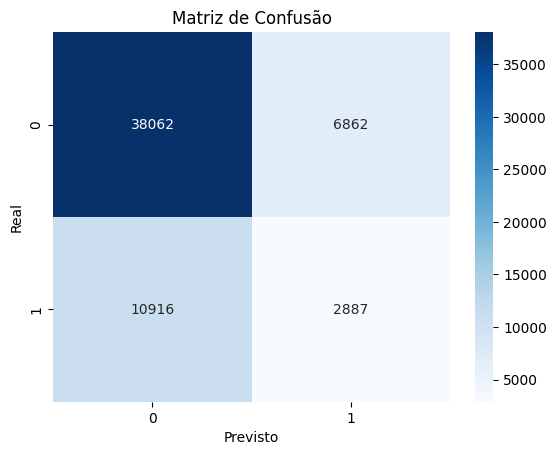

In [55]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")

plt.show()

In [56]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

SCHEDULED_DEPARTURE    0.227033
DISTANCE               0.175078
DAY_OF_WEEK            0.167253
DESTINATION_AIRPORT    0.144024
ORIGIN_AIRPORT         0.140671
AIRLINE                0.068261
DEP_HOUR               0.042346
IS_WEEKEND             0.008708
DISTANCE_CAT_media     0.007960
PERIODO_DIA_manha      0.005815
dtype: float64

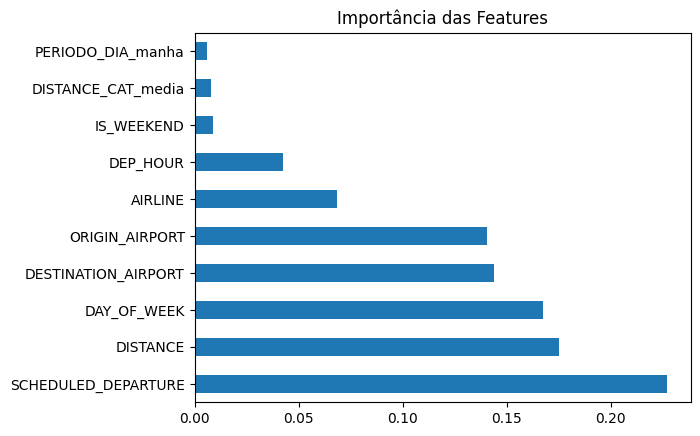

In [57]:
importances.head(10).plot(kind="barh")

plt.title("Importância das Features")
plt.show()